# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Diana Qisthin Thoniyah
- **Email:** cdcc299d6x2345@devacademy.id
- **ID Dicoding:** CDCC299D6X2345

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Faktor apa saja yang berhubungan dengan lonjakan penyewaan sepeda di atas rerata harian sepanjang tahun 2011?
- **Pertanyaan 2:** Jam berapa penyewaan sepeda mengalami peningkatan baik pada hari kerja maupun libur berdasarkan data per jam tahun 2011-2012?
- **Pertanyaan 3:** Bagaimana perbandingan rerata penyewaan harian antara pengguna casual dengan registered pada setiap musim tahun 2012?

## Import Semua Packages/Library yang Digunakan

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

#### Load df Day

In [64]:
file_id = '1lB8FgL2ahWzxveqjrBdBuetmJR-C3A15'
url = f'https://drive.google.com/uc?export=download&id={file_id}'
day_df = pd.read_csv(url)
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:** (Opsional)
- Dataset day_df terdiri dari 16 kolom, mulai dari instant sebagai nomor urut hingga cnt sebagai total dari penyewaan casual dan registered
- Dataset day_df menampilkan data penyewaan harian, dilengkapi dengan kolom suhu, musim, dan cuaca
- Data dimulai dari tanggal 1 Januari 2011

#### Load df Hour

In [65]:
file_id = '1dLPMV7fwcrDen9zNKKXgIiSTZLsPQmm_'
url = f'https://drive.google.com/uc?export=download&id={file_id}'
hour_df = pd.read_csv(url)
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


Insight: (Opsional)

- Dataset hour_df terdiri dari 17 kolom, kolom hr (hour) sebagai tambahan dataset penyewaan hour
- Menampilkan data penyewaan per jam dilengkapi dengan informasi musim, cuaca, dan suhu

### Assessing Data

Menilai tabel day_df

In [66]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [67]:
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [68]:
day_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [69]:
print("Jumlah duplikasi: ",day_df.duplicated().sum())

Jumlah duplikasi:  0


In [70]:
Q1 = day_df['cnt'].quantile(0.25)
Q3 = day_df['cnt'].quantile(0.75)
IQR = Q3 - Q1

outliers = day_df[(day_df['cnt'] < Q1 - 1.5*IQR) | (day_df['cnt'] > Q3 + 1.5*IQR)]
print(f"Jumlah outlier pada kolom cnt: {len(outliers)}")

Jumlah outlier pada kolom cnt: 0


Menilai tabel hour_df

In [71]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [72]:
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [73]:
hour_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [74]:
print("Jumlah duplikasi: ",hour_df.duplicated().sum())

Jumlah duplikasi:  0


In [75]:
Q1 = hour_df['cnt'].quantile(0.25)
Q3 = hour_df['cnt'].quantile(0.75)
IQR = Q3 - Q1

outliers = hour_df[(hour_df['cnt'] < Q1 - 1.5*IQR) | (hour_df['cnt'] > Q3 + 1.5*IQR)]
print(f"Jumlah outlier pada kolom cnt: {len(outliers)}")

Jumlah outlier pada kolom cnt: 505


#### Identifying incorrect datatype problem

In [76]:
print(day_df['dteday'].dtype)
print(hour_df['dteday'].dtype)

object
object


**Steps to Take:**
- Mengubah tipe data kolom dteday pada day_df dari object menjadi datetime
- Mengubah tipe data kolom dteday pada hour_df dari object menjadi datetime
- Membiarkan outlier yang ada pada kolom cnt dataset hour_df karena merupakan data yang valid (total penyewaan casual dan registered)

**Insight:** (Opsional)
- Masalah yang ditemukan adalah kesalahan tipe data pada kolom dteday pada kedua dataset
- Terdapat 505 outlier pada kolom cnt di hour_df
- Tidak ada masalah duplikasi atau missing value pada kedua dataset

### Cleaning Data

#### Fixing incorrect datatype problem

In [77]:
datetime_columns = ["dteday"]

for column in datetime_columns:
    day_df[column] = pd.to_datetime(day_df[column])
    hour_df[column] = pd.to_datetime(hour_df[column])

In [78]:
print(day_df['dteday'].dtype)
print(hour_df['dteday'].dtype)

datetime64[ns]
datetime64[ns]


**Insight:** (Opsional)
- Tipe data kolom dteday pada kedua dataset sudah diperbaiki dan menunjukkan tipe data yang seharusnya, yaitu datetime

## Exploratory Data Analysis (EDA)

### Explore day_df

In [79]:
day_df.sample(5)

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
160,161,2011-06-10,2,0,6,0,5,1,1,0.755000,0.703292,0.605000,0.140554,815,3771,4586
221,222,2011-08-10,3,0,8,0,3,1,1,0.766667,0.684983,0.424167,0.200258,884,3896,4780
470,471,2012-04-15,2,1,4,0,0,0,1,0.606667,0.573875,0.507917,0.225129,2846,4286,7132
435,436,2012-03-11,1,1,3,0,0,0,1,0.361739,0.359670,0.476957,0.222587,1658,3253,4911
39,40,2011-02-09,1,0,2,0,3,1,2,0.134783,0.144283,0.494783,0.188839,53,1552,1605


In [80]:
day_df.describe(include="all")

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2012-01-01 00:00:00,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000
std,211.165812,NaN,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452


In [81]:
day_df.instant.is_unique

True

### Explore hour_df

In [82]:
hour_df.sample(5)

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
3051,3052,2011-05-12,2,0,5,1,0,4,1,1,0.46,0.4545,0.88,0.2239,1,16,17
5397,5398,2011-08-17,3,0,8,19,0,3,1,1,0.76,0.6970,0.55,0.2239,50,297,347
1379,1380,2011-03-02,1,0,3,18,0,3,1,1,0.46,0.4545,0.23,0.4925,8,193,201
17339,17340,2012-12-30,1,1,12,8,0,0,0,1,0.24,0.1970,0.52,0.4627,1,32,33
1049,1050,2011-02-16,1,0,2,11,0,3,1,1,0.34,0.3030,0.34,0.2985,7,59,66


In [83]:
hour_df.describe(include="all")

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2012-01-02 04:08:34.552045568,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
min,1.0000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000
std,5017.0295,NaN,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599


In [84]:
hour_df.instant.is_unique

True

### Explore Pertanyaan 1

In [85]:
day_2011 = day_df[day_df['yr'] == 0]
rerata_harian = day_2011['cnt'].mean()
print(f"Rerata harian 2011: {rerata_harian:.2f}")

Rerata harian 2011: 3405.76


In [86]:
print(day_2011.groupby('season')['cnt'].mean())

season
1    1666.666667
2    3775.173913
3    4464.361702
4    3664.460674
Name: cnt, dtype: float64


In [87]:
print(day_2011.groupby('weathersit')['cnt'].mean())

weathersit
1    3694.986726
2    3088.096774
3    1674.133333
Name: cnt, dtype: float64


In [88]:
print(day_2011.groupby('workingday')['cnt'].mean())

workingday
0    3363.817391
1    3425.056000
Name: cnt, dtype: float64


### Explore Pertanyaan 2

In [89]:
print("Rerata penyewaan per jam (hari kerja vs libur):")
print(hour_df.groupby(['hr', 'workingday'])['cnt'].mean())

Rerata penyewaan per jam (hari kerja vs libur):
hr  workingday
0   0              90.800000
    1              36.786290
1   0              69.508696
    1              16.552632
2   0              53.171053
    1               8.683778
3   0              25.775330
    1               4.942553
4   0               8.264317
    1               5.429787
5   0               8.689189
    1              24.913131
6   0              18.742358
    1             102.500000
7   0              43.406926
    1             290.612903
8   0             105.653680
    1             477.006048
9   0             171.623377
    1             241.518145
10  0             255.909091
    1             135.366935
11  0             315.316017
    1             158.229839
12  0             366.259740
    1             200.820926
13  0             372.731602
    1             198.429719
14  0             364.645022
    1             183.572289
15  0             358.813853
    1             201.331325
16  0    

### Explore Pertanyaan 3

In [90]:
day_2012 = day_df[day_df['yr'] == 1]
print("Rerata casual vs registered per musim 2012:")
print(day_2012.groupby('season')[['casual', 'registered']].mean())

Rerata casual vs registered per musim 2012:
             casual   registered
season                          
1        430.736264  3100.560440
2       1369.108696  4840.380435
3       1389.797872  5434.446809
4        864.820225  4927.044944


**Insight:** (Opsional)
Berdasarkan hasil EDA yang telah dilakukan, berikut insight yang didapat:
- Berdasarkan hasil describe(), data day_df dan hour_df tidak memiliki anomali pada nilai-nilainya
- Rerata harian penyewaan sepeda pada tahun 2011 adalah 3405.76, dengan musim Fall (3) rerata tertinggi dan musim Spring (1) terendah
- Cuaca cerah (weathersit 1) memiliki rerata penyewaan tertinggi, sementara cuaca hujan/salju (weathersit 3) paling rendah
- Perbedaan rerata penyewaan antara hari kerja dan hari libur tidak signifikan
- Pada hari kerja, penyewaan memuncak di jam 8 pagi dan 17-18 sore
- Pada hari libur, penyewaan tertinggi di rentang jam 11-15 siang
- Pengguna registered mendominasi penyewaan di semua musim dibandingkan casual, keduanya mencapai puncak di musim Fall (3)

## Visualization & Explanatory Analysis

### Pertanyaan 1: Faktor apa saja yang berhubungan dengan lonjakan penyewaan sepeda di atas rerata harian sepanjang tahun 2011?

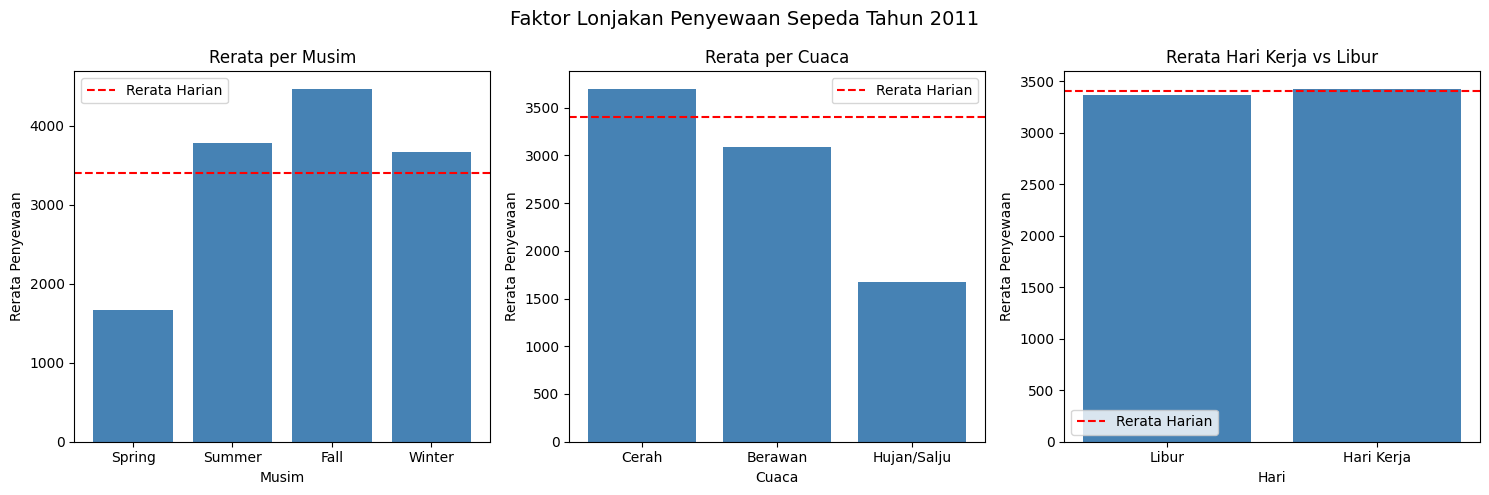

In [91]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Faktor Lonjakan Penyewaan Sepeda Tahun 2011', fontsize=14)

# Rerata per musim
season_avg = day_2011.groupby('season')['cnt'].mean()
axes[0].bar(['Spring','Summer','Fall','Winter'], season_avg, color='steelblue')
axes[0].axhline(y=rerata_harian, color='red', linestyle='--', label='Rerata Harian')
axes[0].set_title('Rerata per Musim')
axes[0].set_xlabel('Musim')
axes[0].set_ylabel('Rerata Penyewaan')
axes[0].legend()

# Rerata per cuaca
weather_avg = day_2011.groupby('weathersit')['cnt'].mean()
axes[1].bar(['Cerah','Berawan','Hujan/Salju'], weather_avg, color='steelblue')
axes[1].axhline(y=rerata_harian, color='red', linestyle='--', label='Rerata Harian')
axes[1].set_title('Rerata per Cuaca')
axes[1].set_xlabel('Cuaca')
axes[1].set_ylabel('Rerata Penyewaan')
axes[1].legend()

# Rerata hari kerja vs libur
workingday_avg = day_2011.groupby('workingday')['cnt'].mean()
axes[2].bar(['Libur','Hari Kerja'], workingday_avg, color='steelblue')
axes[2].axhline(y=rerata_harian, color='red', linestyle='--', label='Rerata Harian')
axes[2].set_title('Rerata Hari Kerja vs Libur')
axes[2].set_xlabel('Hari')
axes[2].set_ylabel('Rerata Penyewaan')
axes[2].legend()

plt.tight_layout()
plt.show()

### Pertanyaan 2: Jam berapa penyewaan sepeda mengalami peningkatan baik pada hari kerja maupun libur berdasarkan data per jam tahun 2011-2012?

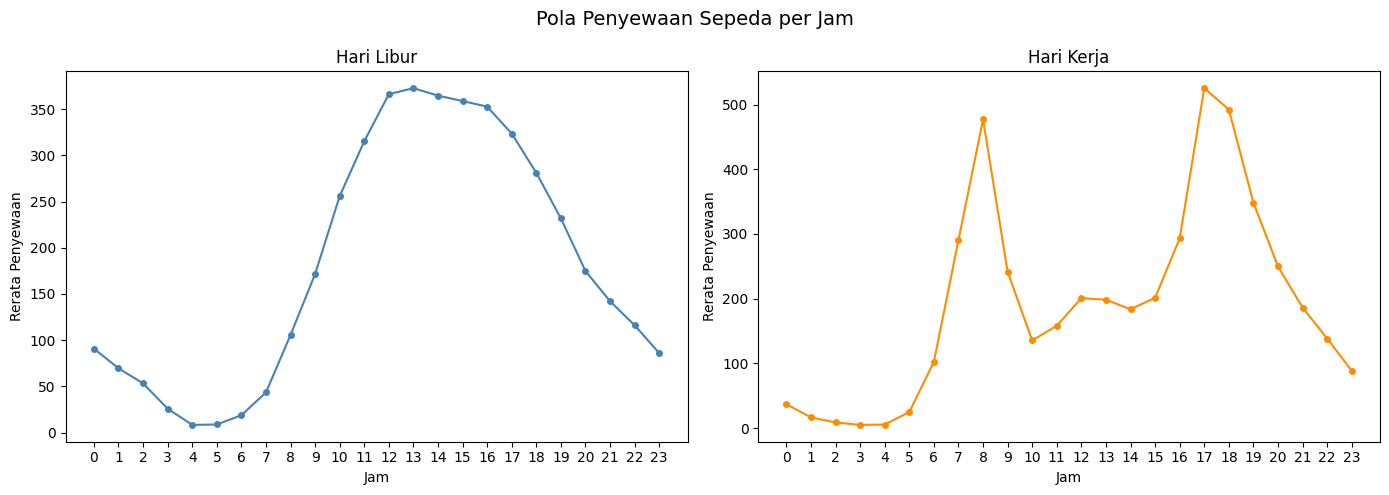

In [92]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Pola Penyewaan Sepeda per Jam', fontsize=14)

workingday_labels = {0: 'Hari Libur', 1: 'Hari Kerja'}
colors = {0: 'steelblue', 1: 'darkorange'}

for wd in [0, 1]:
    data = hour_df[hour_df['workingday'] == wd].groupby('hr')['cnt'].mean()
    axes[wd].plot(data.index, data.values, color=colors[wd], marker='o', markersize=4)
    axes[wd].set_title(workingday_labels[wd])
    axes[wd].set_xlabel('Jam')
    axes[wd].set_ylabel('Rerata Penyewaan')
    axes[wd].set_xticks(range(0, 24))

plt.tight_layout()
plt.show()

### Pertanyaan 3: Bagaimana perbandingan rerata penyewaan harian antara pengguna casual dengan registered pada setiap musim tahun 2012?

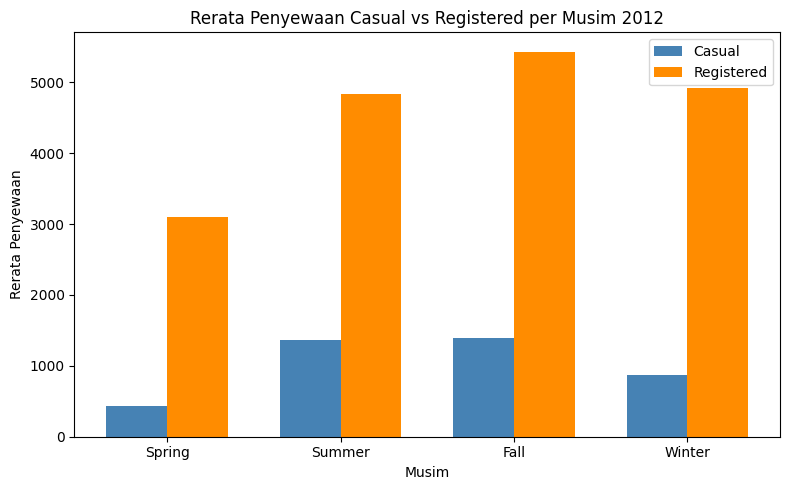

In [93]:
fig, ax = plt.subplots(figsize=(8, 5))

season_labels = ['Spring', 'Summer', 'Fall', 'Winter']
day_2012_season = day_2012.groupby('season')[['casual', 'registered']].mean()

x = np.arange(len(season_labels))
width = 0.35

ax.bar(x - width/2, day_2012_season['casual'], width, label='Casual', color='steelblue')
ax.bar(x + width/2, day_2012_season['registered'], width, label='Registered', color='darkorange')

ax.set_title('Rerata Penyewaan Casual vs Registered per Musim 2012')
ax.set_xlabel('Musim')
ax.set_ylabel('Rerata Penyewaan')
ax.set_xticks(x)
ax.set_xticklabels(season_labels)
ax.legend()

plt.tight_layout()
plt.show()

**Insight:** (Opsional)
- Musim Fall memiliki rerata penyewaan tertinggi dan jauh melampaui rerata harian, sementara musim Spring paling rendah
- Cuaca cerah berhubungan positif dengan lonjakan penyewaan, sedangkan cuaca hujan/salju paling rendah
- Perbedaan banyaknya penyewa antara hari kerja dengan libur tidak signifikan
- Hari kerja menunjukkan pola bimodal dengan puncak jam 8 pagi dan 17 sore
- Hari libur menunjukkan pola satu puncak di jam 12-13 siang
- Pengguna registered mendominasi penyewaan di semua musim dibandingkan casual
- Pengguna registered lebih konsisten di semua musim, sedangkan casual lebih fluktuatif dan sangat dipengaruhi musim

## Analisis Lanjutan (Opsional)

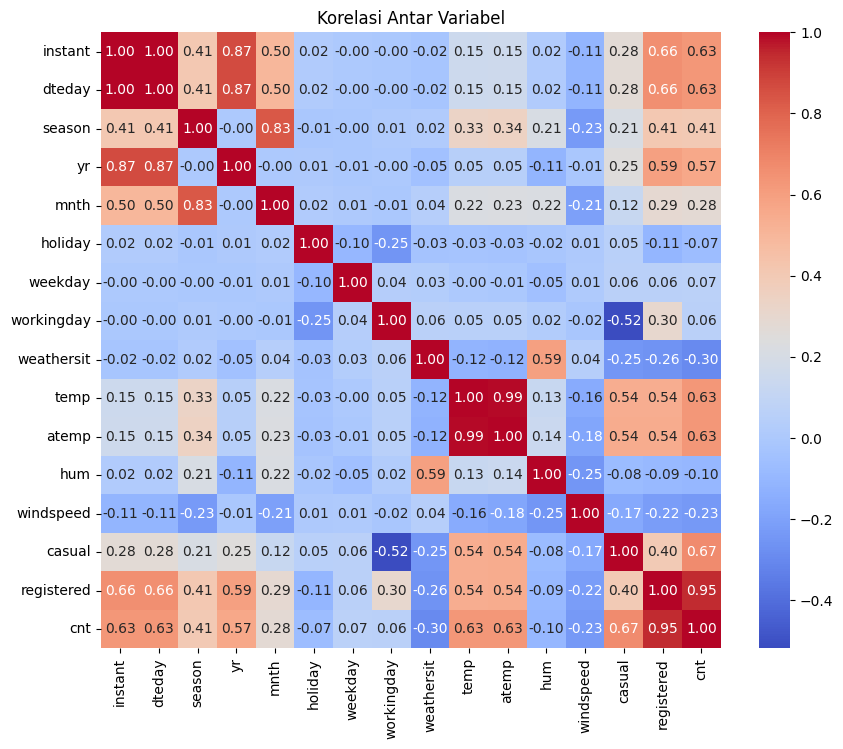

In [94]:
# Heatmap korelasi
plt.figure(figsize=(10, 8))
sns.heatmap(day_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Korelasi Antar Variabel')
plt.show()

**Insight:**

Variabel yang paling berkorelasi dengan total penyewaan (disandingkan dengan cnt) adalah registered (0.95) dan suhu/temp (0.63), sementara cuaca buruk (weathersit) berkorelasi negatif terhadap penyewaan.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Faktor yang berhubungan dengan lonjakan penyewaan sepeda di atas rerata harian tahun 2011 adalah musim Fall (gugur), cuaca cerah, dan hari kerja. Musim Fall mencatat rerata tertinggi (~4464) jauh melampaui rerata harian (3405.76), cuaca cerah mendorong penyewaan di atas rerata, sementara perbedaan antara hari kerja dengan libur tidak signifikan
- **Conclusion pertanyaan 2:** Penyewaan pada hari kerja memuncak pada dua titik, pukul 8 pagi dan 17 sore, sementara hari libur memuncak pada pukul 13
- **Conclusion pertanyaan 3:** Pengguna registered unggul penyewaan di seluruh musim pada tahun 2012 dibandingkan casual. Keduanya mencapai puncak di musim Fall dan terendah di musim Spring. Hanya saja, pengguna registered lebih konsisten, sedangkan casual lebih fluktuatif dan sangat dipengaruhi musim

**Rekomendasi Action Item:**
- Tingkatkan ketersediaan dan promosi sepeda pada musim Fall dan saat cuaca cerah untuk memaksimalkan lonjakan permintaan
- Tambahkan sepeda terutama untuk jam-jam puncak (pukul 8 dan 17) di hari kerja
- Buat program membership/registered untuk mengkonversi pengguna casual menjadi registered agar penyewaan lebih stabil di semua musim
- Buat promo khusus di musim Spring untuk mendorong penyewaan di musim terendah